# Module 4: Data Visualization
## Notebook 2: Distributions and Relationships

**Responsible partner:** FERIT Osijek, Croatia — Mario Dudjak (`mario.dudjak@ferit.hr`)  
**GitHub:** `MarioDudjak` / `dudjakmario@hotmail.com`

**Estimated duration:** 55–65 minutes


## 1. How to use this notebook

This notebook continues the first notebook of Module 5.
It focuses on simple plot types that help us understand data before we move to more advanced analysis.

Try to pay attention to two things:
1. what each plot shows well, and
2. what questions it helps answer.

This is especially important for learners who are new to data science, because choosing the correct plot is often more valuable than using a complex one.


## 2. Learning goals

By the end of this notebook, you should be able to:
- interpret distributions with histograms and boxplots,
- investigate relationships between numeric variables with scatter plots,
- compute and visualize simple correlation matrices,
- compare grouped values using bar plots and matrix-style heatmaps.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(7)


## 3. Why distributions and relationships matter

Before fitting models or drawing conclusions, we should understand our data.

Useful questions include:
- Are the values concentrated around a typical level?
- Are there very small or very large values?
- Is the distribution symmetric or skewed?
- Do two variables rise together?
- Are some stations or regions systematically different?

This notebook introduces common plots that help answer such questions.


## 4. Histograms

A **histogram** shows how values are distributed across intervals (bins).

We will generate a simple example of PM2.5 concentration measurements.


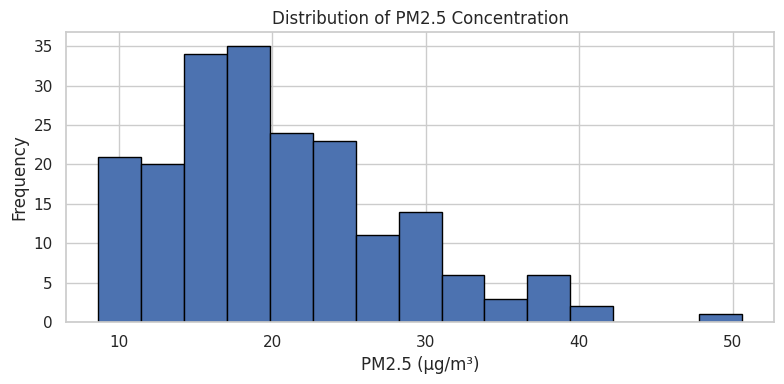

In [2]:
pm25 = np.random.gamma(shape=4, scale=4, size=200) + 5

plt.figure(figsize=(8, 4))
plt.hist(pm25, bins=15, edgecolor="black")
plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Interpretation and discussion

A histogram helps us inspect:
- the central tendency of the data,
- the spread of the data,
- skewness,
- possible extreme values.

In environmental data, histograms are often used for pollutant concentrations, rainfall, wind speed, and temperature anomalies.


## 5. Comparing distributions across groups with boxplots

A **boxplot** summarizes a distribution using:
- the median,
- the lower and upper quartiles,
- whiskers,
- and possible outliers.

Let us simulate PM10 concentrations from three stations.


In [3]:
station_df = pd.DataFrame({
    "station": np.repeat(["Urban", "Suburban", "Rural"], 60),
    "pm10": np.concatenate([
        np.random.normal(42, 8, 60),
        np.random.normal(34, 6, 60),
        np.random.normal(26, 5, 60)
    ])
})

station_df.head()


,station,pm10
0,Urban,42.580061
1,Urban,36.184769
2,Urban,40.117210
3,Urban,36.371260
4,Urban,40.615685


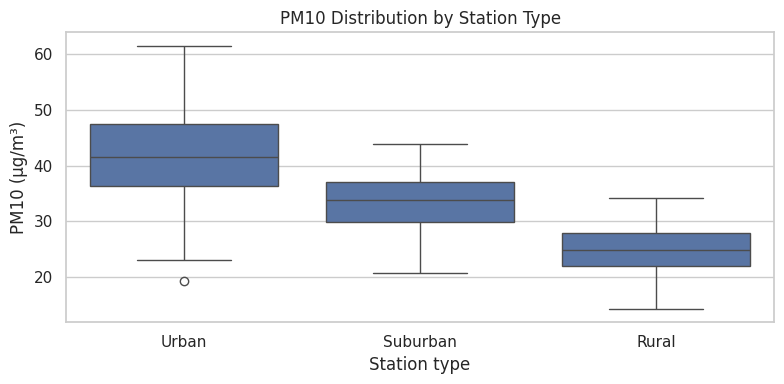

In [4]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=station_df, x="station", y="pm10")
plt.title("PM10 Distribution by Station Type")
plt.xlabel("Station type")
plt.ylabel("PM10 (µg/m³)")
plt.tight_layout()
plt.show()


### Interpretation and discussion

Boxplots are helpful when we want to compare distributions, not just averages.

They make it easier to see:
- which group has the highest typical values,
- which group is more variable,
- whether extreme values are present.


## 6. Scatter plots for relationships between continuous variables

A **scatter plot** is useful for exploring the relationship between two continuous variables.

For example, particulate matter may increase when traffic intensity increases.


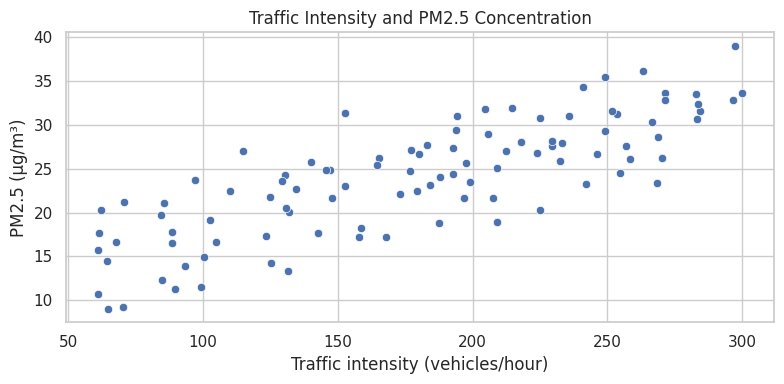

In [5]:
traffic = np.random.uniform(50, 300, 100)
pm25_scatter = 10 + 0.08 * traffic + np.random.normal(0, 4, 100)

traffic_df = pd.DataFrame({
    "traffic": traffic,
    "pm25": pm25_scatter
})

plt.figure(figsize=(8, 4))
sns.scatterplot(data=traffic_df, x="traffic", y="pm25")
plt.title("Traffic Intensity and PM2.5 Concentration")
plt.xlabel("Traffic intensity (vehicles/hour)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


### Interpretation and discussion

A scatter plot helps us see:
- whether a relationship exists,
- whether it looks positive or negative,
- whether it appears linear,
- whether there are unusual observations.

The plot above suggests a **positive relationship**: higher traffic intensity is often associated with higher PM2.5 values.


## 7. Adding a regression line

A regression line can help summarize the trend visually.


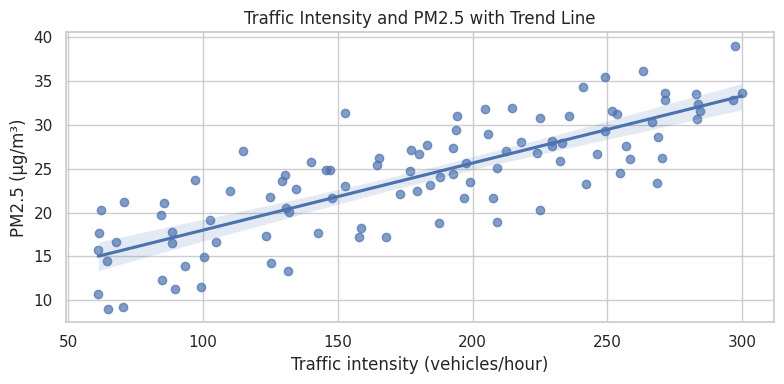

In [6]:
plt.figure(figsize=(8, 4))
sns.regplot(data=traffic_df, x="traffic", y="pm25", scatter_kws={"alpha": 0.7})
plt.title("Traffic Intensity and PM2.5 with Trend Line")
plt.xlabel("Traffic intensity (vehicles/hour)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


This does **not** prove causality, but it helps us summarize an observed association.


## 8. Correlation heatmaps

A **correlation matrix** summarizes pairwise relationships between numeric variables.  
A **heatmap** provides a visual representation of that matrix.

Let us create a small DataFrame with several environmental variables.


In [7]:
env_df = pd.DataFrame({
    "pm25": np.random.normal(25, 6, 120),
    "pm10": np.random.normal(38, 8, 120),
    "no2": np.random.normal(21, 5, 120),
    "temperature": np.random.normal(17, 7, 120),
    "humidity": np.random.normal(68, 10, 120)
})

env_df["pm10"] = env_df["pm25"] * 1.2 + np.random.normal(0, 4, 120)
env_df["no2"] = env_df["pm25"] * 0.5 + np.random.normal(8, 3, 120)

env_df.head()


,pm25,pm10,no2,temperature,humidity
0,29.259686,30.826876,25.664813,4.259819,69.772740
1,25.690554,24.829010,23.232482,23.900028,60.901725
2,13.267797,20.855893,19.086548,15.890522,74.736109
3,18.602367,25.744273,23.419838,28.216795,83.226149
4,19.453131,26.628981,21.284058,2.577041,102.163838


In [8]:
corr = env_df.corr(numeric_only=True)
corr


,pm25,pm10,no2,temperature,humidity
pm25,1.000000,0.865552,0.679962,0.011265,-0.008851
pm10,0.865552,1.000000,0.567125,-0.085938,-0.027154
no2,0.679962,0.567125,1.000000,-0.075166,-0.030187
temperature,0.011265,-0.085938,-0.075166,1.000000,-0.045102
humidity,-0.008851,-0.027154,-0.030187,-0.045102,1.000000


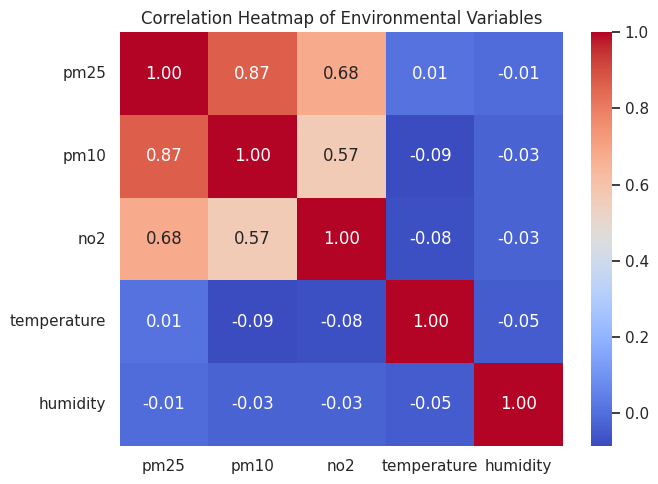

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Environmental Variables")
plt.tight_layout()
plt.show()


### Interpretation and discussion

A correlation heatmap helps us quickly inspect:
- which variables move together,
- which relationships are weak,
- whether variables appear positively or negatively related.

For beginners, it is important to remember:
- correlation does not imply causation,
- correlation only summarizes linear association,
- results should be interpreted in context.


## 9. Bar plots for categorical comparisons

Now let us compare average pollutant concentration across regions.


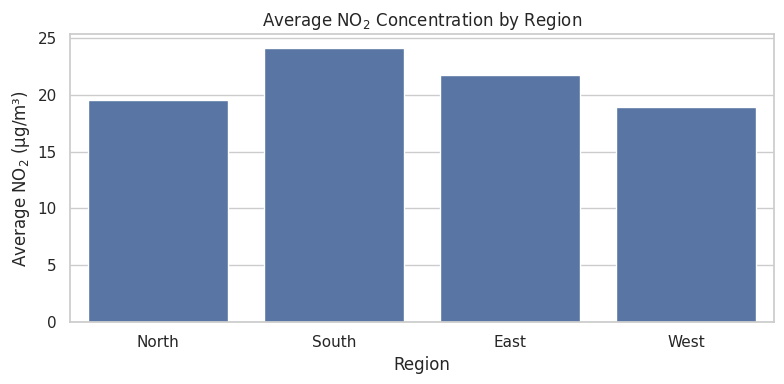

In [10]:
region_df = pd.DataFrame({
    "region": ["North", "South", "East", "West"],
    "avg_no2": [19.5, 24.1, 21.7, 18.9]
})

plt.figure(figsize=(8, 4))
sns.barplot(data=region_df, x="region", y="avg_no2", color="C0")
plt.title("Average NO$_2$ Concentration by Region")
plt.xlabel("Region")
plt.ylabel("Average NO$_2$ (µg/m³)")
plt.tight_layout()
plt.show()


Bar plots are useful when:
- the x-axis is categorical,
- the y-axis is a summary value,
- the goal is comparison across groups.

They are not ideal for showing the full distribution of each group.  
For that purpose, boxplots are usually more informative.


## 10. Heatmaps for categorical-style summaries

Heatmaps can also summarize a table of values.

Suppose we have mean PM2.5 values by station and season.


In [11]:
season_station = pd.DataFrame({
    "station": ["Station A", "Station A", "Station A",
                "Station B", "Station B", "Station B",
                "Station C", "Station C", "Station C"],
    "season": ["Spring", "Summer", "Winter"] * 3,
    "pm25": [18, 12, 27, 22, 15, 31, 16, 11, 24]
})

pivot_table = season_station.pivot(index="station", columns="season", values="pm25")
pivot_table


season,Spring,Summer,Winter
station,,,
Station A,18,12,27
Station B,22,15,31
Station C,16,11,24


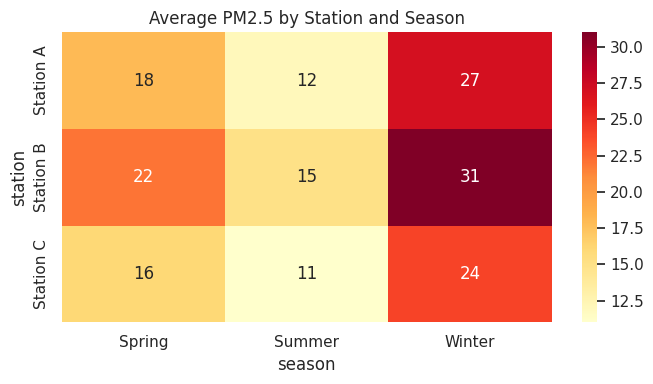

In [12]:
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_table, annot=True, cmap="YlOrRd", fmt=".0f")
plt.title("Average PM2.5 by Station and Season")
plt.tight_layout()
plt.show()


This kind of plot is useful for comparing many category combinations at once.


## 11. Choosing the right plot

Here is a simple rule-of-thumb guide:

- **Line plot**: change over ordered values or time
- **Histogram**: distribution of one numeric variable
- **Boxplot**: compare distributions across groups
- **Scatter plot**: relationship between two numeric variables
- **Bar plot**: compare summary values across categories
- **Heatmap**: compare many values in matrix form


## 12. Guided practice

Try the following tasks:
1. Create a histogram for a new numeric variable.
2. Create a boxplot comparing at least three groups.
3. Create a scatter plot for two continuous variables.
4. Compute a correlation matrix and draw a heatmap.
5. Create a bar plot comparing average values across categories.


In [13]:
# Write your code here.


## 13. Mini exercise

Create a small environmental dataset with these columns:
- `temperature`
- `humidity`
- `pm25`
- `station_type`

Then:
1. draw a histogram for `pm25`,
2. draw a boxplot of `pm25` by `station_type`,
3. draw a scatter plot of `temperature` vs `pm25`,
4. compute and visualize a correlation heatmap for the numeric columns.


In [14]:
# Write your code here.


## 14. Summary

In this notebook, you learned how to:
- inspect distributions with histograms,
- compare grouped distributions with boxplots,
- analyze continuous relationships with scatter plots,
- summarize pairwise numeric associations with correlation heatmaps,
- compare categories with bar plots and matrix-style heatmaps.

Together with Notebook 1, this provides a complete introductory Python session on static data visualization for Module 5.
